In [18]:
import glob
import os
import re
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
from scipy.stats import entropy, norm

In [29]:
model_names = ["MP4_beta0.1", "MP4_beta0.5", "MP4_beta0.8", "MP4_beta1", "MP4_beta1.5", "MP4_beta4", "MP4_beta10"]
num_of_latent_features = [2]
beta_values = [0.1, 0.5, 0.8, 1, 1.5, 4, 10]

loss_dir = "losses/MS_MP4"
base_dir = "training_results/CD38/MP4/"

In [7]:
def parse_loss_file(filename):
    """
    Parse a single loss file with lines like:
      "Epoch 0: Total Loss 213967.447097, Recon Loss 213961.755306, KL Loss 5.692201"
    Returns:
      epochs, total_losses, recon_losses, kl_losses (all lists of floats).
    """
    epochs = []
    total_losses = []
    recon_losses = []
    kl_losses = []
    
    with open(filename, "r") as f:
        for line in f:
            # Use a regex to extract the numbers
            match = re.search(
                r"Epoch\s+(\d+).*Total\s+Loss\s+([\d.]+).*Recon\s+Loss\s+([\d.]+).*KL\s+Loss\s+([\d.]+)",
                line
            )
            if match:
                epoch_str, total_str, recon_str, kl_str = match.groups()
                epochs.append(int(epoch_str))
                total_losses.append(float(total_str))
                recon_losses.append(float(recon_str))
                kl_losses.append(float(kl_str))
    return epochs, total_losses, recon_losses, kl_losses


def parse_all_loss_files(loss_dir, models, latent_dims):
    """
    Parse all combination of (model, latent_dim) within 'loss_dir' 
    using the naming pattern: 
        {model}_4000epoch_latent{latent_dim}.txt
    
    Returns a dictionary of the form:
       data[(model, dim)] = {
         'epochs': [ ... ],
         'total':  [ ... ],
         'recon':  [ ... ],
         'kl':     [ ... ],
       }
    """
    data = {}
    for model in models:
        filename = os.path.join(loss_dir, f"{model}_latent2.txt")
        if not os.path.isfile(filename):
            print(f"WARNING: File not found: {filename}")
            continue
        epochs, total, recon, kl = parse_loss_file(filename)
        data[model] = {
            'epochs': epochs,
            'total': total,
            'recon': recon,
            'kl': kl
        }
    return data


In [8]:
def summarize_final_and_min_losses(model_names, loss_dir):
    results = []
    for model in model_names:
        filename = os.path.join(loss_dir, f"{model}_latent2.txt")
        if not os.path.isfile(filename):
            continue

        with open(filename, "r") as f:
            lines = f.readlines()

        min_total = min_recon = min_kl = float("inf")
        final_total = final_recon = final_kl = None

        for line in lines:
            parts = line.strip().split(',')
            total_val = float(parts[0].split("Total Loss")[-1].strip())
            recon_val = float(parts[1].split("Recon Loss")[-1].strip())
            kl_val = float(parts[2].split("KL Loss")[-1].strip())

            min_total = min(min_total, total_val)
            min_recon = min(min_recon, recon_val)
            min_kl = min(min_kl, kl_val)

            final_total = total_val
            final_recon = recon_val
            final_kl = kl_val

        results.append({
            'model': model,
            'final_total': final_total,
            'final_recon': final_recon,
            'final_kl': final_kl,
            'min_total': min_total,
            'min_recon': min_recon,
            'min_kl': min_kl
        })

    best_total = min(results, key=lambda x: x['final_total'])
    best_recon = min(results, key=lambda x: x['final_recon'])
    best_kl = min(results, key=lambda x: x['final_kl'])

    print("Best final total loss:", best_total)
    print("Best final recon loss:", best_recon)
    print("Best final KL loss:", best_kl)

In [9]:
def plot_losses_by_type(data, min_epoch=500):
    for loss_type in ['total', 'recon', 'kl']:
        plt.figure()
        final_vals = []

        for model, content in data.items():
            epochs = content['epochs']
            losses = content[loss_type]

            start_idx = next((i for i, ep in enumerate(epochs) if ep >= min_epoch), None)
            if start_idx is None:
                continue

            ep_slice = epochs[start_idx:]
            loss_slice = losses[start_idx:]
            plt.plot(ep_slice, loss_slice, label=model)

            if epochs:
                final_vals.append((model, epochs[-1], losses[-1]))

        final_vals.sort(key=lambda x: x[2], reverse=True)
        text_lines = [f"{m}: {val:.2f} (ep={ep})" for m, ep, val in final_vals]
        text_block = "\n".join(text_lines)

        plt.subplots_adjust(right=0.7)
        plt.text(
            1.02, 0.5, text_block,
            transform=plt.gca().transAxes,
            va='center', ha='left',
            bbox=dict(facecolor='white', alpha=0.8)
        )

        plt.xlabel(f"Epoch (≥ {min_epoch})")
        plt.ylabel(f"{loss_type.capitalize()} Loss")
        plt.title(f"Beta-VAE Models — {loss_type.capitalize()} Loss (Epoch ≥ {min_epoch})")
        plt.legend()
        plt.show()

In [19]:
def calculate_kl_divergence(latent_samples, num_bins=100):
    kl_divergences = []
    for dim in range(latent_samples.shape[1]):
        samples = latent_samples[:, dim]
        hist, bin_edges = np.histogram(samples, bins=num_bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        gaussian_pdf = norm.pdf(bin_centers)

        hist += 1e-10
        hist /= np.sum(hist)
        gaussian_pdf += 1e-10
        gaussian_pdf /= np.sum(gaussian_pdf)

        kl_div = entropy(hist, gaussian_pdf)
        kl_divergences.append(kl_div)
    return kl_divergences

In [31]:
def visualize_latent_space_and_kl(beta_values, base_dir):
    for beta in beta_values:
        model_dir = os.path.join(base_dir, f"beta{beta}")

        if not os.path.exists(model_dir):
            print(f"Folder not found: {model_dir}")
            continue

        latent_file = os.path.join(model_dir, "latent_train.txt")
        labels_file = os.path.join(model_dir, "latent_train_labels.txt")
        patient_labels_file = os.path.join(model_dir, "latent_train_patient_labels.txt")

        if not (os.path.exists(latent_file) and os.path.exists(labels_file) and os.path.exists(patient_labels_file)):
            print(f"Missing files in {model_dir}")
            continue

        latent_vis = np.loadtxt(latent_file, delimiter=",")
        labels = np.loadtxt(labels_file)
        patient_labels = np.loadtxt(patient_labels_file)

        # Plot by labels
        unique_labels = np.unique(labels)
        label_color_map = {label: color for label, color in zip(unique_labels, ["#003366", "#FF4500"])}

        plt.figure(figsize=(8, 6))
        for label in unique_labels:
            mask = labels == label
            plt.scatter(latent_vis[mask, 0], latent_vis[mask, 1],
                        color=label_color_map[label], alpha=0.7, s=10, label=f"Label {label}")
        plt.xlabel("Latent Dimension 1")
        plt.ylabel("Latent Dimension 2")
        plt.title(f"beta{beta} - Latent Space by Labels")
        plt.legend()
        plt.show()

        # Plot by patient IDs
        unique_patients = np.unique(patient_labels)
        patient_color_list = ["#006400", "#4B0082", "#8B0000", "#008B8B", "#8B4513", "#483D8B"]
        patient_color_map = {pid: patient_color_list[i % len(patient_color_list)] for i, pid in enumerate(unique_patients)}

        plt.figure(figsize=(8, 6))
        for pid in unique_patients:
            mask = patient_labels == pid
            plt.scatter(latent_vis[mask, 0], latent_vis[mask, 1],
                        color=patient_color_map[pid], alpha=0.7, s=10, label=f"Patient {pid}")
        plt.xlabel("Latent Dimension 1")
        plt.ylabel("Latent Dimension 2")
        plt.title(f"beta{beta} - Latent Space by Patient IDs")
        plt.legend(title="Patient IDs", loc="best", fontsize="small", ncol=2)
        plt.show()

        # Compute KL divergence for the latent distribution
        kl_divs = calculate_kl_divergence(latent_vis)
        for i, kl in enumerate(kl_divs):
            print(f"beta{beta} - KL Divergence (dim {i+1}): {kl:.4f}")
        print("-" * 60)

In [15]:
data = parse_all_loss_files(loss_dir, model_names, 2)

In [16]:
summarize_final_and_min_losses(model_names, loss_dir)

Best final total loss: {'model': 'MP4_beta1', 'final_total': 5699.079188, 'final_recon': 5685.843472, 'final_kl': 13.235724, 'min_total': 5682.522411, 'min_recon': 5669.261492, 'min_kl': 7.156944}
Best final recon loss: {'model': 'MP4_beta1', 'final_total': 5699.079188, 'final_recon': 5685.843472, 'final_kl': 13.235724, 'min_total': 5682.522411, 'min_recon': 5669.261492, 'min_kl': 7.156944}
Best final KL loss: {'model': 'MP4_beta1', 'final_total': 5699.079188, 'final_recon': 5685.843472, 'final_kl': 13.235724, 'min_total': 5682.522411, 'min_recon': 5669.261492, 'min_kl': 7.156944}


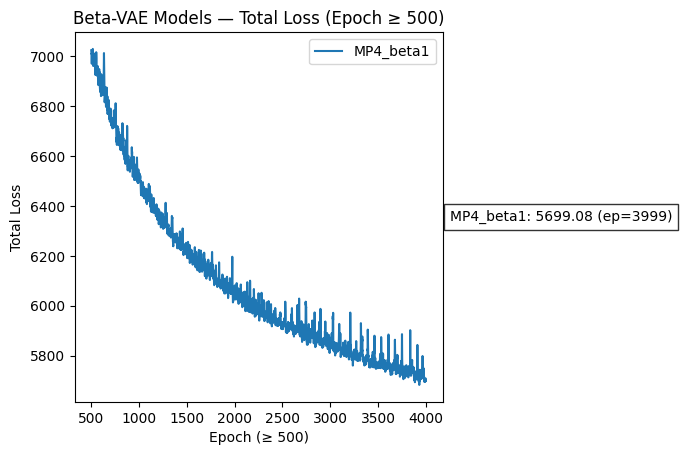

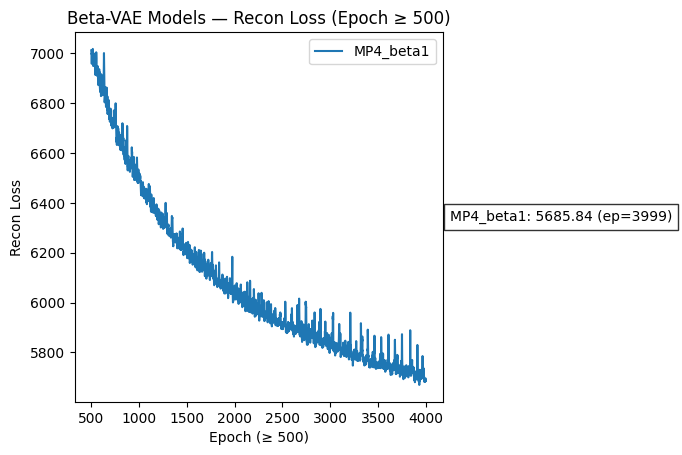

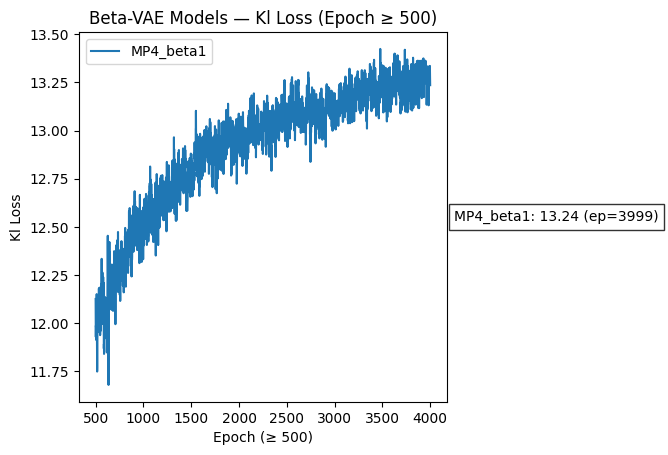

In [17]:
plot_losses_by_type(data, min_epoch=500)

Folder not found: training_results/CD38/MP4/beta0.1
Folder not found: training_results/CD38/MP4/beta0.5
Folder not found: training_results/CD38/MP4/beta0.8


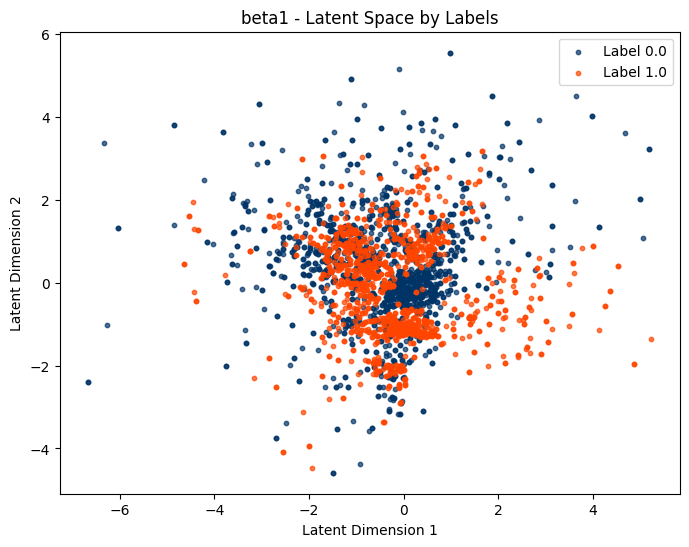

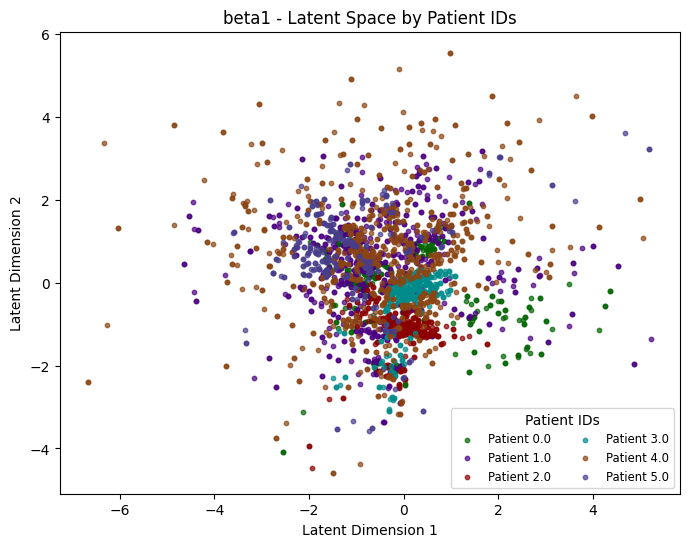

beta1 - KL Divergence (dim 1): 0.2381
beta1 - KL Divergence (dim 2): 0.2002
------------------------------------------------------------
Folder not found: training_results/CD38/MP4/beta1.5
Missing files in training_results/CD38/MP4/beta4
Folder not found: training_results/CD38/MP4/beta10


In [32]:
visualize_latent_space_and_kl(beta_values, base_dir)